In [1]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import font_manager

from pandas.api.types import CategoricalDtype
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['xtick.major.size'] = 3
mpl.rcParams['ytick.major.size'] = 3

# Figure 4A

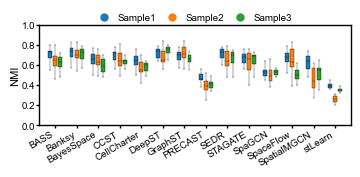

In [4]:
df_mean = pd.read_csv("df_sccube_sim1.csv", index_col=0)
df_mean['Replicate'] = 'Unknown'
df_mean['test_sample'] = df_mean['test_sample'].astype(str)
df_mean.loc[(df_mean['test_sample'] == '151507') | 
            (df_mean['test_sample'] == '151508') | 
            (df_mean['test_sample'] == '151509') |
            (df_mean['test_sample'] == '151510'), 'Replicate'] = 'Sample1'
df_mean.loc[(df_mean['test_sample'] == '151669') | 
            (df_mean['test_sample'] == '151670') | 
            (df_mean['test_sample'] == '151671') |
            (df_mean['test_sample'] == '151672'), 'Replicate'] = 'Sample2'
df_mean.loc[(df_mean['test_sample'] == '151673') | 
            (df_mean['test_sample'] == '151674') | 
            (df_mean['test_sample'] == '151675') |
            (df_mean['test_sample'] == '151676'), 'Replicate'] = 'Sample3'
data1 = df_mean.copy()
replicate_order = ['Sample1', 'Sample2', 'Sample3']
data1['Replicate'] = pd.Categorical(data1['Replicate'], categories=replicate_order, ordered=True)
method_colors = {
    "Sample1": "#1F77B4", 
    "Sample2": "#FF7F0E",
    "Sample3": "#2CA02C"
}
metrics = ['NMI']
box_width = 0.18
gap = 0.06
method_spacing = 1
width_inch = 9 / 2.54 
height_inch = 4 / 2.54
def make_box_legend_handle(color):
    return Line2D(
        [0], [0],
        color='black', linestyle='-', linewidth=1,
        marker='s', markerfacecolor=color, markeredgecolor='black', markersize=10
    )

fig, ax = plt.subplots(figsize=(width_inch, height_inch))

for col_idx, data in enumerate([data1]):
    methods = sorted(list(set(data['Method'])))
    for metric in metrics:
        for i, sample in enumerate(replicate_order):
            offset = (i - (len(replicate_order) - 1) / 2) * (box_width + gap)
            for j, method in enumerate(methods):
                subset = data[(data['Method'] == method) & (data['Replicate'] == sample)][metric]
                position = j * method_spacing + offset
                ax.boxplot(subset,
                           positions=[position],
                           widths=box_width,
                           patch_artist=True,
                           showfliers=False,
                           boxprops=dict(facecolor=method_colors[sample], linewidth=0.25),
                           medianprops=dict(color='black', linewidth=0.25),
                           whiskerprops=dict(linewidth=0.25),
                           capprops=dict(linewidth=0.25))

        ax.set_xticks(np.arange(len(methods)) * method_spacing)
        ax.set_xticklabels(methods, rotation=30, fontsize=7, ha='right')
        ax.set_ylabel(metric, fontsize=8, labelpad=1)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.set_ylim(0, 1)
        ax.tick_params(axis='both', which='both', labelsize=7, pad=1, length=2, width=1, color='black', labelcolor='black')
        ax.grid(False)
        for spine in ['top', 'right', 'bottom', 'left']:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_linewidth(1)
        from matplotlib.lines import Line2D
        handles = [
            Line2D([0], [0],
                   marker='o',
                   color='none',
                   markerfacecolor=method_colors[sample],
                   markeredgecolor='none',
                   markersize=6)
            for sample in replicate_order
        ]
        ax.legend(
            handles=handles,
            labels=replicate_order,
            loc='upper center',
            bbox_to_anchor=(0.5, 1.2),
            ncol=3,
            fontsize=7,
            handlelength=1.2,
            handleheight=0.8,
            columnspacing=1.0,
            frameon=False
        )
plt.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.26, hspace=0.6, wspace=0.3)
#plt.savefig("Figure4A.pdf")
plt.show()

# Figure 4B

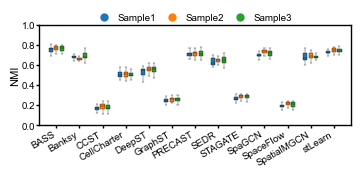

In [5]:
df_mean2 = pd.read_csv("df_sccube_sim2.csv", index_col=0)
df_mean2['Replicate'] = df_mean2['test_sample'].str.extract(r'^(.*?)_')
df_mean2['Replicate'] = df_mean2['Replicate'].replace({'Animal1': 'Sample1', 'Animal2': 'Sample2', 'Animal3': 'Sample3'})
data2 = df_mean2.copy()
replicate_order = ['Sample1', 'Sample2', 'Sample3']
data2['Replicate'] = pd.Categorical(data2['Replicate'], categories=replicate_order, ordered=True)
metrics = ['NMI']
method_colors = {
    "Sample1": "#1F77B4", 
    "Sample2": "#FF7F0E",
    "Sample3": "#2CA02C"
}
box_width = 0.18
gap = 0.06
method_spacing = 1
width_inch = 9 / 2.54 
height_inch = 4 / 2.54
def make_box_legend_handle(color):
    return Line2D(
        [0], [0],
        color='black', linestyle='-', linewidth=1,
        marker='s', markerfacecolor=color, markeredgecolor='black', markersize=10
    )

fig, ax = plt.subplots(figsize=(width_inch, height_inch))

for col_idx, data in enumerate([data2]):
    methods = sorted(list(set(data['Method'])))
    for metric in metrics:
        for i, sample in enumerate(replicate_order):
            offset = (i - (len(replicate_order) - 1) / 2) * (box_width + gap)
            for j, method in enumerate(methods):
                subset = data[(data['Method'] == method) & (data['Replicate'] == sample)][metric]
                position = j * method_spacing + offset
                ax.boxplot(subset,
                           positions=[position],
                           widths=box_width,
                           patch_artist=True,
                           showfliers=False,
                           boxprops=dict(facecolor=method_colors[sample], linewidth=0.25),
                           medianprops=dict(color='black', linewidth=0.25),
                           whiskerprops=dict(linewidth=0.25),
                           capprops=dict(linewidth=0.25))

        ax.set_xticks(np.arange(len(methods)) * method_spacing)
        ax.set_xticklabels(methods, rotation=30, fontsize=7, ha='right')
        ax.set_ylabel(metric, fontsize=8, labelpad=1)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.set_ylim(0, 1)
        ax.tick_params(axis='both', which='both', labelsize=7, pad=1, length=2, width=1, color='black', labelcolor='black')
        ax.grid(False)
        for spine in ['top', 'right', 'bottom', 'left']:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_linewidth(1)
        from matplotlib.lines import Line2D
        handles = [
            Line2D([0], [0],
                   marker='o',
                   color='none',
                   markerfacecolor=method_colors[sample],
                   markeredgecolor='none',
                   markersize=6)
            for sample in replicate_order
        ]
        ax.legend(
            handles=handles,
            labels=replicate_order,
            loc='upper center',
            bbox_to_anchor=(0.5, 1.2),
            ncol=3,
            fontsize=7,
            handlelength=1.2,
            handleheight=0.8,
            columnspacing=1.0,
            frameon=False
        )
plt.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.26, hspace=0.6, wspace=0.3)
plt.savefig("Figure4B.pdf")
plt.show()

# Figure 4C

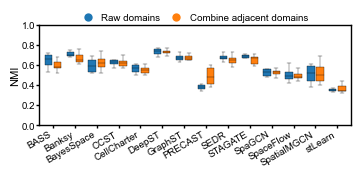

In [8]:
df_mean3 = pd.read_csv("df_sccube_sim3.csv", index_col=0)
df_mean3['Method'] = df_mean3['Method'].str.replace('SpaMGCN', 'SpatialMGCN', regex=False)
data1 = df_mean3.copy()
data1['Simulation'] = data1['Simulation'].str.replace('raw domains', 'Raw domains', regex=False)
data1['Simulation'] = data1['Simulation'].str.replace('6 domains', 'Combine adjacent domains', regex=False)
simulation_order = ['Raw domains', 'Combine adjacent domains']
data1['Simulation'] = pd.Categorical(data1['Simulation'], categories=simulation_order, ordered=True)
metrics = ['NMI']
method_colors = {
    "Raw domains": "#1F77B4", 
    "Combine adjacent domains": "#FF7F0E"
}
box_width = 0.4
gap = 0.1
method_spacing = 1.2
width_inch = 9 / 2.54 
height_inch = 4 / 2.54
def make_box_legend_handle(color):
    return Line2D(
        [0], [0],
        color='black', linestyle='-', linewidth=1,
        marker='s', markerfacecolor=color, markeredgecolor='black', markersize=10
    )
fig, ax = plt.subplots(figsize=(width_inch, height_inch))
data = data1.copy()
methods = sorted(list(set(data['Method'])))
for col_idx, data in enumerate([data1]):
    methods = sorted(list(set(data['Method'])))
    for metric in metrics:
        for i, sample in enumerate(simulation_order):
            offset = (i - (len(simulation_order) - 1) / 2) * (box_width + gap)
            for j, method in enumerate(methods):
                subset = data[(data['Method'] == method) & (data['Simulation'] == sample)][metric]
                position = j * method_spacing + offset
                ax.boxplot(subset,
                           positions=[position],
                           widths=box_width,
                           patch_artist=True,
                           showfliers=False,
                           boxprops=dict(facecolor=method_colors[sample], linewidth=0.25),
                           medianprops=dict(color='black', linewidth=0.25),
                           whiskerprops=dict(linewidth=0.25),
                           capprops=dict(linewidth=0.25))

        ax.set_xticks(np.arange(len(methods)) * method_spacing)
        ax.set_xticklabels(methods, rotation=30, fontsize=7, ha='right')
        ax.set_ylabel(metric, fontsize=8, labelpad=1)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.set_ylim(0, 1)
        ax.tick_params(axis='both', which='both', labelsize=7, pad=1, length=2, width=1, color='black', labelcolor='black')
        ax.grid(False)
        for spine in ['top', 'right', 'bottom', 'left']:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_linewidth(1)
        from matplotlib.lines import Line2D
        handles = [
            Line2D([0], [0],
                   marker='o',
                   color='none',
                   markerfacecolor=method_colors[sample],
                   markeredgecolor='none',
                   markersize=6)
            for sample in simulation_order
        ]
        ax.legend(
            handles=handles,
            labels=simulation_order,
            loc='upper center',
            bbox_to_anchor=(0.5, 1.2),
            ncol=2,
            fontsize=7,
            handlelength=1.2,
            handleheight=0.8,
            columnspacing=1.0,
            frameon=False
        )
plt.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.26, hspace=0.6, wspace=0.3)
#plt.savefig("Figure4C.pdf")
plt.show()

# Figure 4D

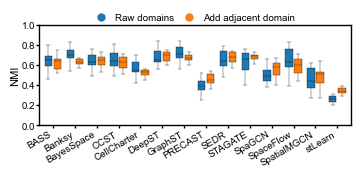

In [7]:
df_mean4 = pd.read_csv("df_sccube_sim4.csv", index_col=0)
df_mean4['Method'] = df_mean4['Method'].str.replace('SpaMGCN', 'SpatialMGCN', regex=False)
data1 = df_mean4.copy()
simulation_order = ['Raw domains', 'Add adjacent domain']
data1['Simulation'] = pd.Categorical(data1['Simulation'], categories=simulation_order, ordered=True)
metrics = ['NMI']
method_colors = {
    "Raw domains": "#1F77B4", 
    "Add adjacent domain": "#FF7F0E"
}
box_width = 0.4
gap = 0.1
method_spacing = 1.2
width_inch = 9 / 2.54 
height_inch = 4 / 2.54
def make_box_legend_handle(color):
    return Line2D(
        [0], [0],
        color='black', linestyle='-', linewidth=1,
        marker='s', markerfacecolor=color, markeredgecolor='black', markersize=10
    )

fig, ax = plt.subplots(figsize=(width_inch, height_inch))
data = data1.copy()
methods = sorted(list(set(data['Method'])))
for col_idx, data in enumerate([data1]):
    methods = sorted(list(set(data['Method'])))
    for metric in metrics:
        for i, sample in enumerate(simulation_order):
            offset = (i - (len(simulation_order) - 1) / 2) * (box_width + gap)
            for j, method in enumerate(methods):
                subset = data[(data['Method'] == method) & (data['Simulation'] == sample)][metric]
                position = j * method_spacing + offset
                ax.boxplot(subset,
                           positions=[position],
                           widths=box_width,
                           patch_artist=True,
                           showfliers=False,
                           boxprops=dict(facecolor=method_colors[sample], linewidth=0.25),
                           medianprops=dict(color='black', linewidth=0.25),
                           whiskerprops=dict(linewidth=0.25),
                           capprops=dict(linewidth=0.25))

        ax.set_xticks(np.arange(len(methods)) * method_spacing)
        ax.set_xticklabels(methods, rotation=30, fontsize=7, ha='right')
        ax.set_ylabel(metric, fontsize=8, labelpad=1)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.set_ylim(0, 1)
        ax.tick_params(axis='both', which='both', labelsize=7, pad=1, length=2, width=1, color='black', labelcolor='black')
        ax.grid(False)
        for spine in ['top', 'right', 'bottom', 'left']:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_linewidth(1)
        from matplotlib.lines import Line2D
        handles = [
            Line2D([0], [0],
                   marker='o',
                   color='none',
                   markerfacecolor=method_colors[sample],
                   markeredgecolor='none',
                   markersize=6)
            for sample in simulation_order
        ]
        ax.legend(
            handles=handles,
            labels=simulation_order,
            loc='upper center',
            bbox_to_anchor=(0.5, 1.2),
            ncol=2,
            fontsize=7,
            handlelength=1.2,
            handleheight=0.8,
            columnspacing=1.0,
            frameon=False
        )
plt.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.26, hspace=0.6, wspace=0.3)
#plt.savefig("Figure4D.pdf")
plt.show()